In [1]:
import torch
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.rcParams['font.family'] = 'SimHei'  # 'SimHei'是黑体的字体名
# matplotlib.rcParams['font.size'] = 14
# import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用中文黑体
plt.rcParams['axes.unicode_minus'] = False  # 确保坐标轴负号显示正常

In [2]:
x = torch.linspace(-10,10,100)
noise = torch.randn(x.shape)
x[:5]

tensor([-10.0000,  -9.7980,  -9.5960,  -9.3939,  -9.1919])

In [3]:
def fn(x):
    
    return 4 + 3*x

$$y = 4+ 3x + noise$$

In [4]:
y = fn(x) + noise

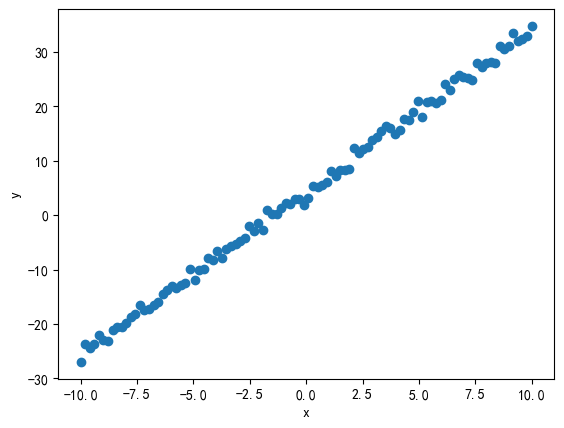

In [5]:
# plt.figure(figsize=(12,8))
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [6]:
n = 1
X = torch.stack([x**i for i in range(n+1)],dim = 0)   #构造特征矩阵

In [7]:
def judge(X):       ##判断特征举证是否可逆
    det = X @ X.T
    det = torch.det(det)
    if det > 0:
        print('XX.T可逆')
        return X
    else:
        print('XX.T不可逆 使用岭回归求解')
        X += 2
        return X

In [8]:
X = judge(X)

XX.T可逆


岭回归求解最优参数
$$ w^* = (XX^{T} + \lambda I)^{-1}Xy$$

In [9]:
w = torch.matmul(torch.inverse(torch.matmul(X,X.T)),X) @ y
w,w.shape

(tensor([4.2381, 2.9906]), torch.Size([2]))

In [10]:
def fn_pre(w,x):
    '''预测函数'''
    sum = 0
    for index,w_ in enumerate(w):
        sum += w_* x**index
    return sum

In [11]:
predict = fn_pre(w,x)

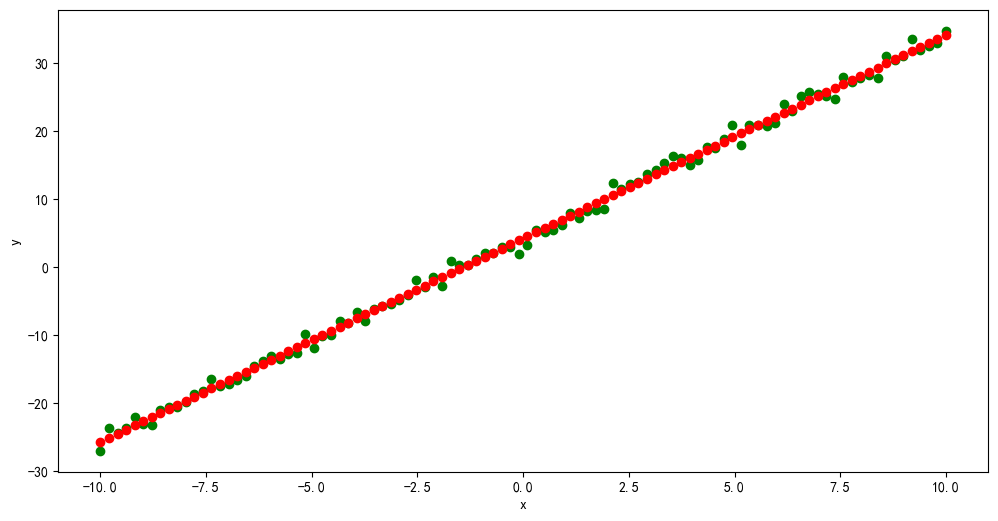

In [12]:
plt.figure(figsize=(12,6))
plt.scatter(x,y,c='g')
plt.scatter(x,predict,c='r')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

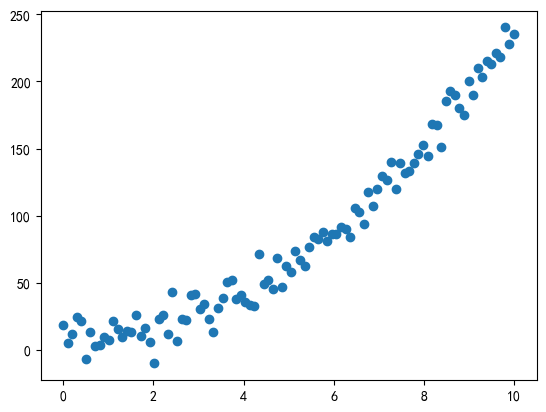

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.linspace(0, 10, 100)
y = 2 * x**2 + 3 * x + 1 + np.random.normal(0, 10, 100)

plt.scatter(x, y)
plt.show()

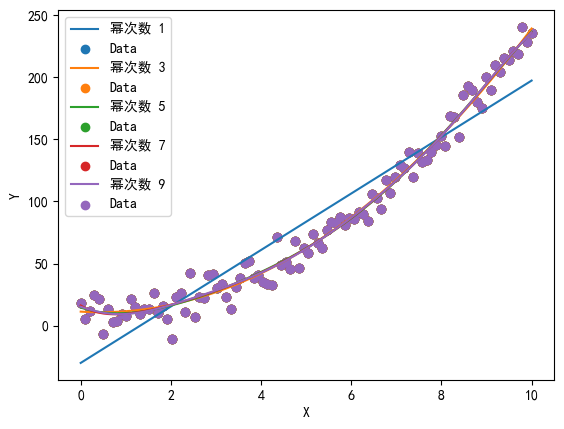

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 假设 x、y 已经是你准备好的数据
# x.shape = (n_samples, ), y.shape = (n_samples, )
# 举例: 
# x = np.linspace(-3, 3, 30)
# y = x**3 + np.random.randn(30)*3  # 仅做示例

# 要尝试的多项式次数
degrees = [1, 3, 5, 7, 9]

for degree in degrees:
    # 1) 根据指定 degree，初始化多项式特征生成器
    poly_features = PolynomialFeatures(degree=degree)
    
    # 2) 对 x 进行形状变换 (n_samples,) -> (n_samples, 1)，然后生成多项式特征
    #   例如 degree=3 时，会在原始 x 的基础上生成 [1, x, x^2, x^3] 四列
    x_poly = poly_features.fit_transform(x[:, np.newaxis])
    
    # 3) 使用线性回归模型对多项式特征进行拟合
    model = LinearRegression()
    model.fit(x_poly, y)
    
    # 4) 使用训练好的模型对同样的 x_poly 进行预测
    y_pred = model.predict(x_poly)
    
    # 5) 可视化：将拟合后的曲线绘制出来
    #   注意：plt.plot 一般用于画连续曲线，plt.scatter 则用于散点图
    plt.plot(x, y_pred, label=f'幂次数 {degree}')  # 拟合曲线
    
# 绘制原始数据的散点图（只需绘制一次即可）
plt.scatter(x, y, color='black', label='Data')

# 设置坐标轴标签与图例
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("不同多项式次数的拟合效果对比")
plt.show()


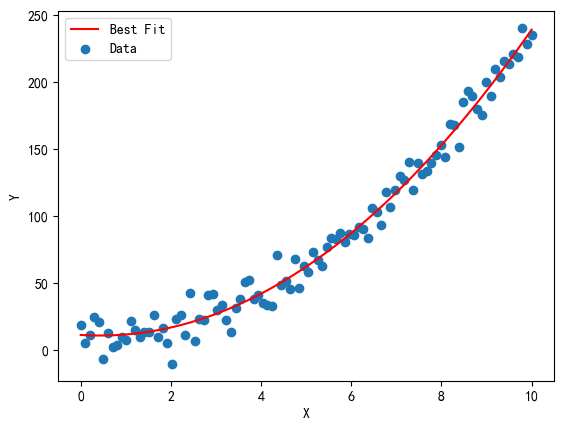

In [17]:
# 以3次多项式为例
poly_features = PolynomialFeatures(degree=3)
x_poly = poly_features.fit_transform(x[:, np.newaxis])
model = LinearRegression()
model.fit(x_poly, y)
y_pred = model.predict(x_poly)

plt.plot(x, y_pred, label='Best Fit',c='r')
plt.scatter(x, y, label='Data')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

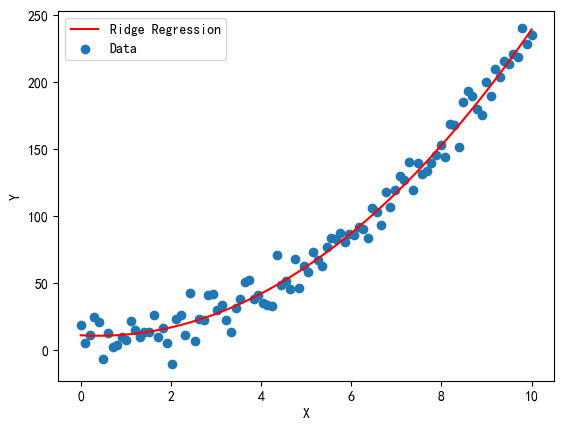

In [18]:
from sklearn.linear_model import Ridge

alpha = 1  # 正则化强度
model = Ridge(alpha=alpha)
model.fit(x_poly, y)
y_pred = model.predict(x_poly)

plt.plot(x, y_pred, label='Ridge Regression',c='r')
plt.scatter(x, y, label='Data')
plt.legend()
plt.xlabel('X')
plt.ylabel("Y")
plt.show()

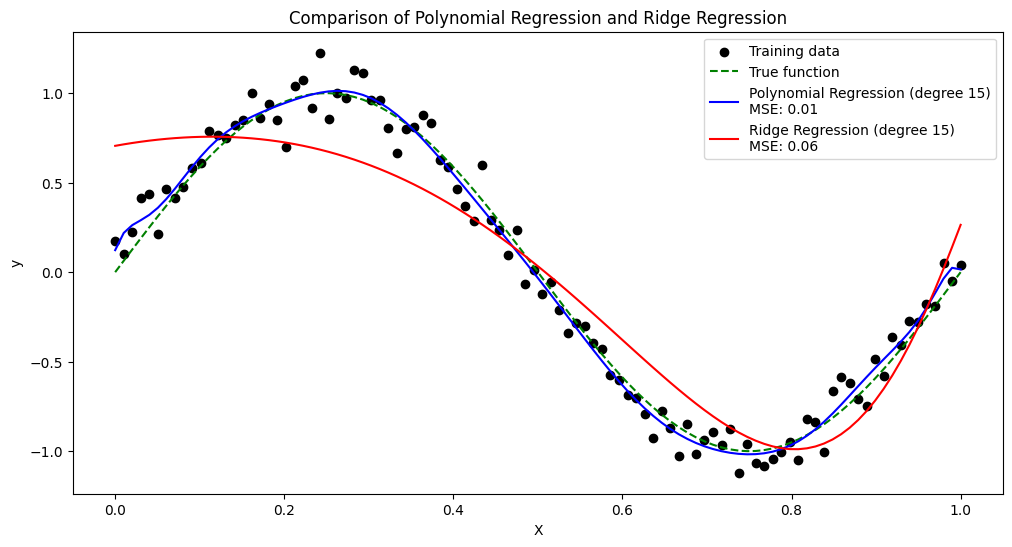

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 生成数据
np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples)
y = np.sin(2 * np.pi * X) + np.random.normal(scale=0.1, size=X.shape)

# 重塑 X 矩阵
X = X[:, np.newaxis]

# 设置多项式的度数（高阶多项式，容易产生过拟合）
degree = 15

# 创建普通多项式回归模型
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
poly_model.fit(X, y)
y_poly_pred = poly_model.predict(X)

# 创建岭回归模型
ridge_model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=0.1))
ridge_model.fit(X, y)
y_ridge_pred = ridge_model.predict(X)

# 生成测试数据
X_test = np.linspace(0, 1, 100)[:, np.newaxis]
y_true = np.sin(2 * np.pi * X_test)

# 预测测试数据
y_poly_test_pred = poly_model.predict(X_test)
y_ridge_test_pred = ridge_model.predict(X_test)

# 计算均方误差
mse_poly = mean_squared_error(y, y_poly_pred)
mse_ridge = mean_squared_error(y, y_ridge_pred)

# 绘制结果
plt.figure(figsize=(12, 6))

# 训练数据和真实函数
plt.scatter(X, y, color='black', label='Training data')
plt.plot(X_test, y_true, color='green', linestyle='--', label='True function')

# 普通多项式回归预测
plt.plot(X_test, y_poly_test_pred, color='blue', label=f'Polynomial Regression (degree {degree})\nMSE: {mse_poly:.2f}')

# 岭回归预测
plt.plot(X_test, y_ridge_test_pred, color='red', label=f'Ridge Regression (degree {degree})\nMSE: {mse_ridge:.2f}')

# 图例和标题
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Comparison of Polynomial Regression and Ridge Regression")
plt.show()
